For clarity the end result is: 5 independent tensors found in Hodge Version



*   1 at order 2: stored in indep_G2
*   3 at order 4: stored in indep_G4_v2
*   1 at order 6: stored in indep_G6_v2





In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import math
import itertools
import numpy as np
from sympy.combinatorics.named_groups import SymmetricGroup
from sympy.combinatorics import Permutation

In [3]:
import string
import networkx as nx
import networkx.algorithms.isomorphism as iso # Replaced by igraph
from collections import Counter, defaultdict # Use defaultdict for graph
from joblib import Parallel, delayed
import time # For basic profiling if needed

In [4]:
%cd /content/drive/MyDrive/Colab\ Notebooks


/content/drive/MyDrive/Colab Notebooks


In [5]:
!pip install python-igraph


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 60.3 MB/s eta 0:00:00


In [6]:
import igraph as ig


In [7]:
from colored_tensor_contraction_graphs import *
import opt_einsum as oe

In [8]:
def hodge_dual(my_form):
    """
    Computes the Hodge dual of a p form in 2p dimensions in a more efficient way
    """
    dual = np.zeros_like(my_form)
    dim = my_form.shape[0]
    p = len(my_form.shape)
    sym_p = SymmetricGroup(p)

    ## Get all partitions of indices into two groups

    all_indices = list(range(dim))

    for subset in itertools.combinations(all_indices, p):
        complement = list(set(all_indices) - set(subset))
        these_indices = list(subset)

        overall_perm = Permutation(these_indices+complement)

        ## Now set all elements of the Hodge dual equal to this value

        for g in sym_p.elements:
            this_perm = tuple(g(complement))
            dual[this_perm] = overall_perm.signature()*g.signature()*my_form[tuple(these_indices)]

    return dual

In [9]:
def random_antisym(d, p):
    """
    Generate a random antisymmetric p-form in d dimensions.
    """
    shape = (d,) * p
    arr = np.random.rand(*shape)
    G = SymmetricGroup(p)
    out = np.zeros(shape)
    # Loop over independent components
    for comp in itertools.combinations(range(d), p):
        val = 0.0
        # Antisymmetrize
        for g in G.elements:
            perm = tuple(g(comp))
            val += arr[perm] * g.signature()
        # Assign to all permuted positions
        for g in G.elements:
            perm = tuple(g(comp))
            out[perm] = val * g.signature()
    return out

def contract_strings(str_list, t1, t2, free_letters):
    """
    Replace the first '?' placeholder in nodes t1 and t2 with the next free letter.
    """
    letter = free_letters[0]
    remaining = free_letters[1:]
    str_list[t1] = str_list[t1].replace('?', letter, 1)
    str_list[t2] = str_list[t2].replace('?', letter, 1)
    return str_list, remaining

def graph_to_einsum(graph):
    """
    Convert a weighted contraction graph into an einsum index string.
    """
    free_letters = list(string.ascii_letters)
    nodes = list(graph.nodes())
    n_nodes = len(nodes)
    # Determine number of indices per tensor from the weighted degree of the first node
    n_indices = graph.degree(nodes[0], weight='weight')
    # Initialize each node's index pattern as '?' placeholders
    letters_list = ['?' * n_indices for _ in range(n_nodes)]
    # Apply each edge's contractions
    for u, v, data in graph.edges(data=True):
        w = data.get('weight', 0)
        for _ in range(w):
            letters_list, free_letters = contract_strings(letters_list, u, v, free_letters)
    return ','.join(letters_list)

First, the inequivalent contractions at order $2$.

In [10]:
G2 = get_colored_graphs(2)
G2

In [11]:
import math
import matplotlib.pyplot as plt
import networkx as nx

def plot_graphs(graph_list, palette={0:"C0", 1:"C3"}):
    """
    Draws all graphs in `graph_list` in a grid, coloring nodes
    according to their 'color' attribute (default: 0→blue, 1→red).
    """
    n = len(graph_list)
    if n == 0:
        return

    # choose grid size ~ square
    cols = int(math.ceil(math.sqrt(n)))
    rows = int(math.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))
    axes = axes.flatten()

    for ax, G in zip(axes, graph_list):
        # extract color attribute and map to plotting colors
        color_attr = nx.get_node_attributes(G, "color")
        node_colors = [ palette.get(color_attr.get(node,0), "gray")
                        for node in G.nodes() ]

        nx.draw(
            G,
            node_color=node_colors,
            edge_color="k",
            with_labels=False,
            node_size=400,
            font_color="white",
            ax=ax
        )
        ax.set_axis_off()

    # hide any extra axes
    for ax in axes[n:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

# ─── Example usage ────────────────────────────────────────────────────────────
# plot_graphs(G2)        # all order-2 graphs
# plot_graphs(G4)        # all order-4 graphs
# plot_graphs(G6_all)    # your full colored list at order-6

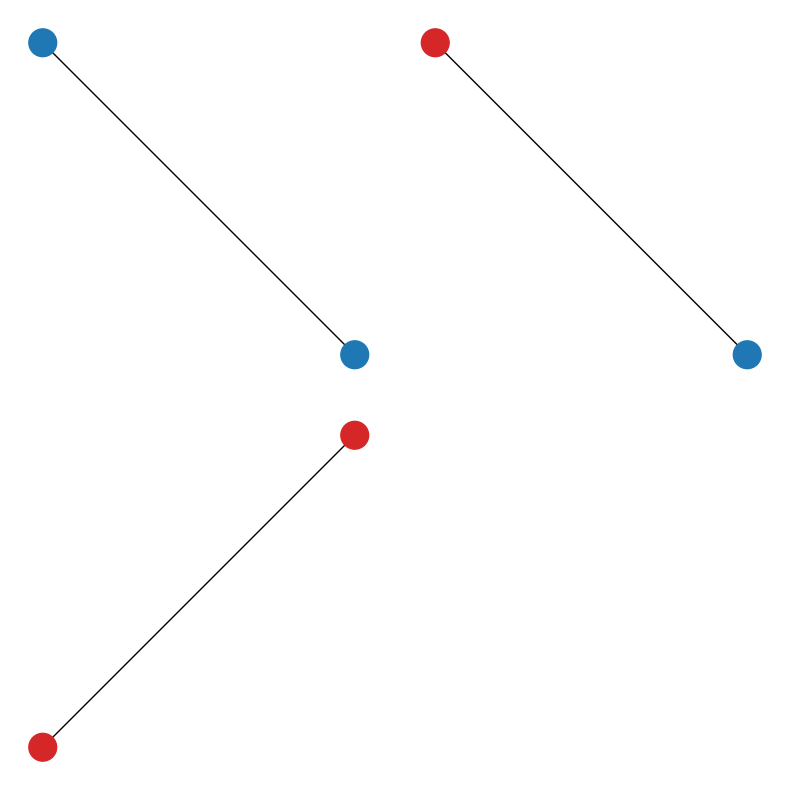

In [12]:
plot_graphs(G2)

In [13]:
data = []

for trial in range(3):
    H     = random_antisym(6, 3)
    Hstar = hodge_dual(H)
    row   = []

    # G2 is your list of order-2 colored graphs
    for G in G2:
        # 1) build the einsum pattern
        pattern = graph_to_einsum(G)               # e.g. "abc,abc" or similar

        # 2) read off each node’s color
        color_attr = nx.get_node_attributes(G, "color")
        #    color 0 → use H, color 1 → use Hstar
        #    nodes are labeled 0..N-1
        tensors = [ H if color_attr[i]==0 else Hstar
                    for i in range(G.number_of_nodes()) ]

        # 3) contract them in that order
        val = oe.contract(pattern, *tensors)
        row.append(float(val))

    data.append(row)

# now `data` is a 3×len(G2) array of floats
print(data)

[[71.01524539860137, -8.881784197001252e-16, 71.01524539860137], [50.563513862924296, 0.0, 50.563513862924296], [99.4777096431654, 4.440892098500626e-16, 99.4777096431654]]


In [14]:
np.linalg.matrix_rank(data)

np.int64(1)

In [15]:
np.linalg.eig(data)

EigResult(eigenvalues=array([ 1.70492955e+02+0.00000000e+00j, -1.12863042e-16+5.17928993e-11j,
       -1.12863042e-16-5.17928993e-11j]), eigenvectors=array([[ 5.36891553e-01+0.00000000e+00j,  6.41119347e-11-1.35771978e-05j,
         6.41119347e-11+1.35771978e-05j],
       [ 3.82271742e-01+0.00000000e+00j, -1.00000000e+00+0.00000000e+00j,
        -1.00000000e+00-0.00000000e+00j],
       [ 7.52074315e-01+0.00000000e+00j, -6.41119373e-11+1.35771978e-05j,
        -6.41119373e-11-1.35771978e-05j]]))

In [16]:
indep_G2 = [G2[0]]

In [17]:
G4 = get_colored_graphs(4)
G4

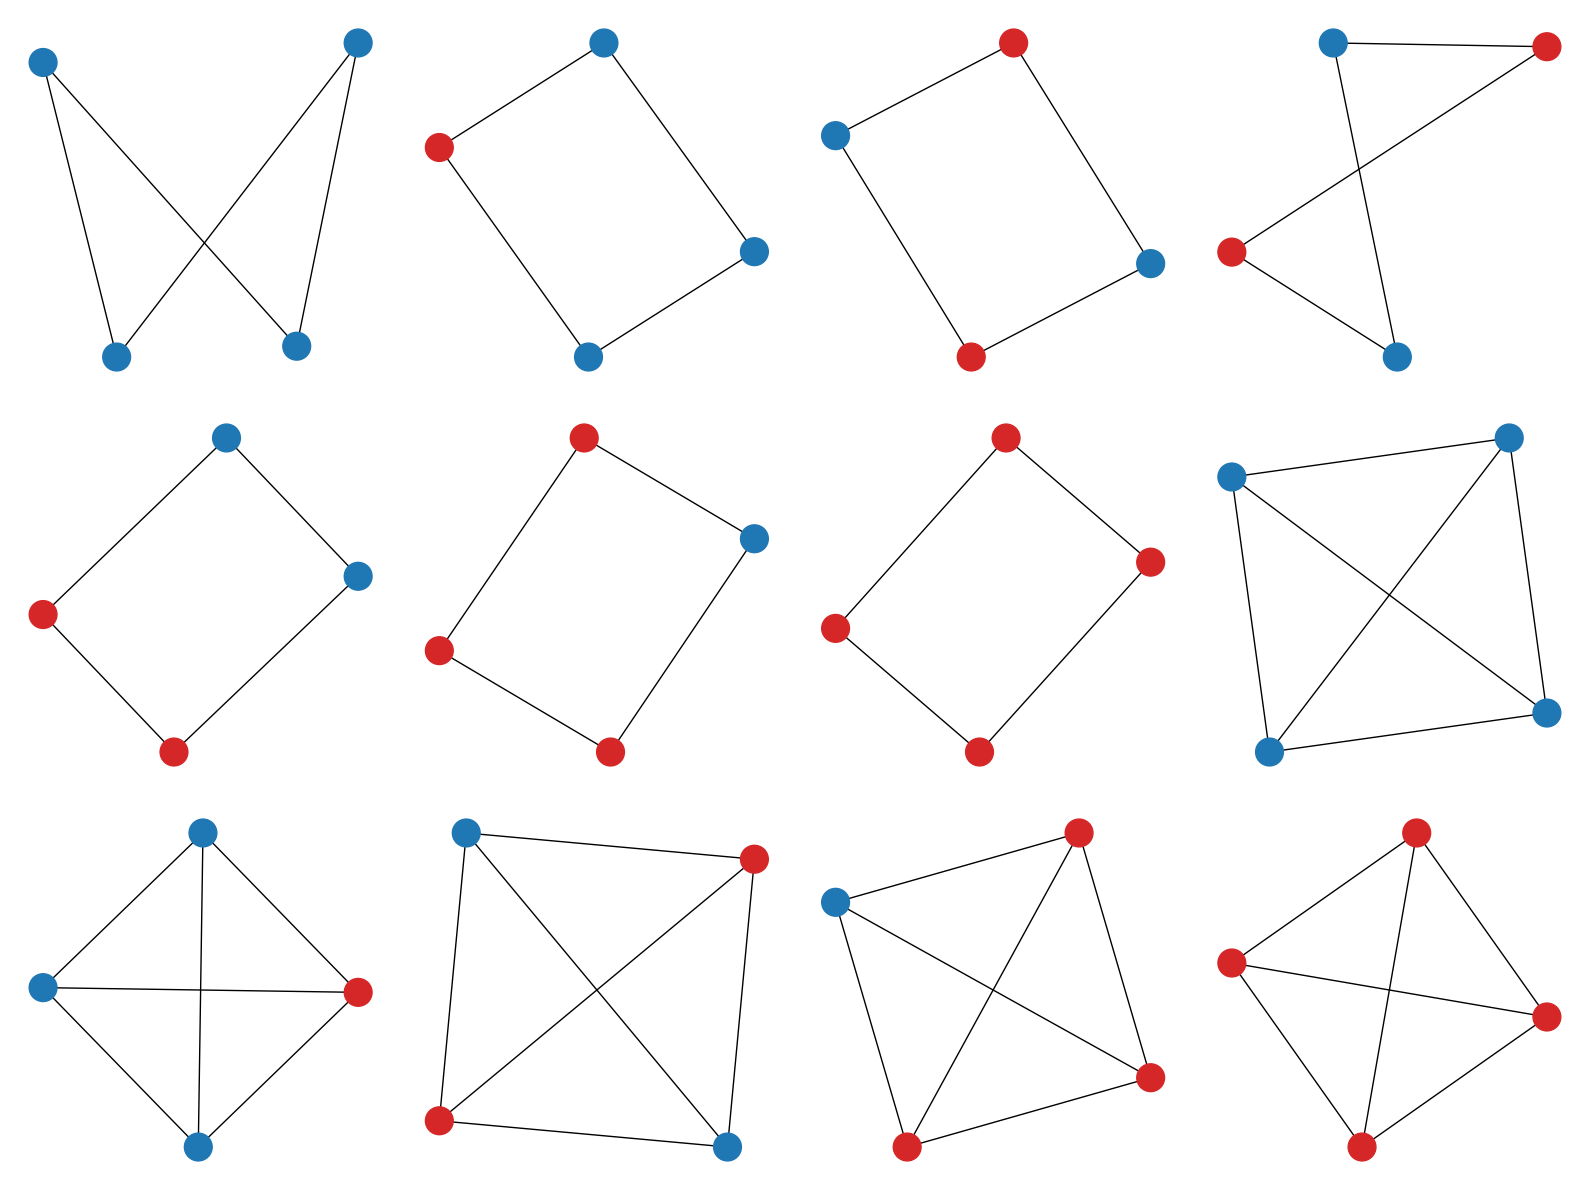

In [18]:
plot_graphs(G4)

In [19]:
#Initial finding of the rank with only order 4 invariants

data = []

for trial in range(12):
    H     = random_antisym(6, 3)
    Hstar = hodge_dual(H)
    row   = []

    # G4 is your list of order-4 colored graphs
    for G in G4:
        # 1) build the einsum pattern
        pattern = graph_to_einsum(G)               # e.g. "abc,abc" or similar

        # 2) read off each node’s color
        color_attr = nx.get_node_attributes(G, "color")
        #    color 0 → use H, color 1 → use Hstar
        #    nodes are labeled 0..N-1
        tensors = [ H if color_attr[i]==0 else Hstar
                    for i in range(G.number_of_nodes()) ]

        # 3) contract them in that order
        val = oe.contract(pattern, *tensors)
        row.append(float(val))

    data.append(row)

# now `data` is a 3×len(G4) array of floats


In [20]:
np.linalg.matrix_rank(data)

np.int64(4)

In [21]:
data = np.array(data).T.tolist()


In [22]:
indep_cols = []   # will hold the selected column-vectors
indep_idx  = []   # will hold their original column indices

for idx, vec in enumerate(data):
    # form the candidate matrix by stacking what we have + this new vec
    M = np.vstack(indep_cols + [vec])   # shape = (k+1, n_samples)

    # if the numeric rank goes up by exactly 1, this vec is independent
    if np.linalg.matrix_rank(M) == len(indep_cols) + 1:
        indep_cols.append(vec)
        indep_idx.append(idx)

print("Independent invariant indices:", indep_idx)

Independent invariant indices: [0, 1, 2, 3]


In [23]:
indep_G4_v1 = [ G4[0], G4[1], G4[2], G4[3]]


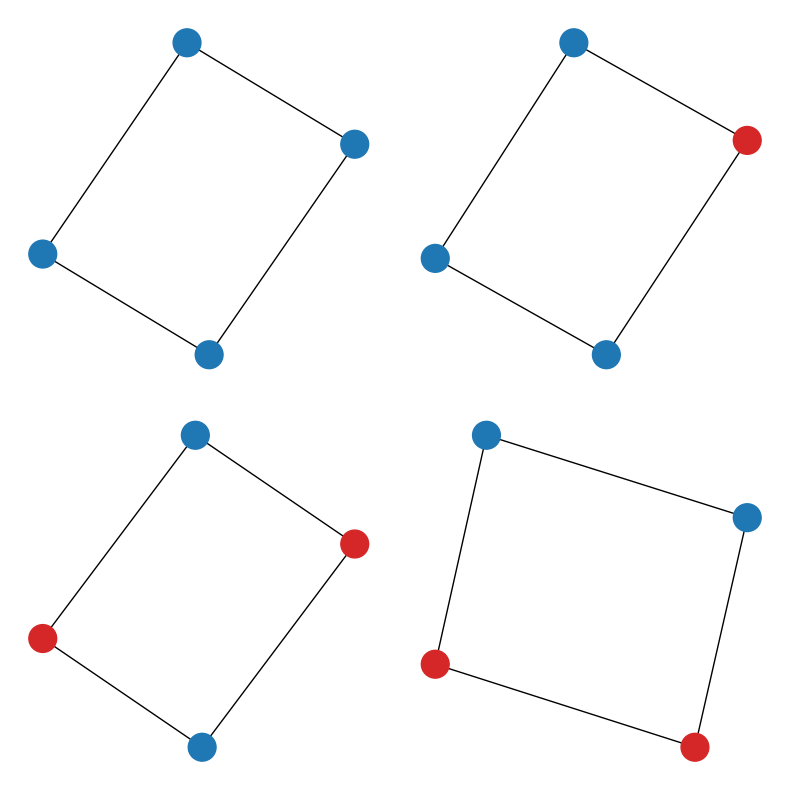

In [24]:
plot_graphs(indep_G4_v1)

In [25]:
#Finding the rank once we add in the invariants built from lower order invariants

data = []

for i in range(5):
    H = random_antisym(6, 3)
    Hstar = hodge_dual(H)
    row   = []
    y2 = []
    y4 =[]

    # G2 is your list of order-2 colored graphs
    for G in indep_G2:
        # 1) build the einsum pattern
        pattern = graph_to_einsum(G)               # e.g. "abc,abc" or similar

        # 2) read off each node’s color
        color_attr = nx.get_node_attributes(G, "color")
        #    color 0 → use H, color 1 → use Hstar
        #    nodes are labeled 0..N-1
        tensors = [ H if color_attr[i]==0 else Hstar
                    for i in range(G.number_of_nodes()) ]

        # 3) contract them in that order
        val = oe.contract(pattern, *tensors)
        y2.append((float(val)))


    for G in indep_G4_v1:
        # 1) build the einsum pattern
        pattern = graph_to_einsum(G)               # e.g. "abc,abc" or similar

        # 2) read off each node’s color
        color_attr = nx.get_node_attributes(G, "color")
        #    color 0 → use H, color 1 → use Hstar
        #    nodes are labeled 0..N-1
        tensors = [ H if color_attr[i]==0 else Hstar
                    for i in range(G.number_of_nodes()) ]

        # 3) contract them in that order
        val = oe.contract(pattern, *tensors)
        y4.append((float(val)))
    row.append(y2[0]*y2[0])
    row.append(y4[0])
    row.append(y4[1])
    row.append(y4[2])
    row.append(y4[3])





    data.append(row)

data = np.matrix(data)

print(data.shape, np.linalg.matrix_rank(data))

(5, 5) 4


In [26]:
np.linalg.matrix_rank(data)

np.int64(4)

In [27]:
#Finding the independent ones

data = []

for i in range(4):
    H = random_antisym(6, 3)
    Hstar = hodge_dual(H)
    row   = []
    y2 = []
    y4 =[]

    # G2 is your list of order-2 colored graphs
    for G in indep_G2:
        # 1) build the einsum pattern
        pattern = graph_to_einsum(G)               # e.g. "abc,abc" or similar

        # 2) read off each node’s color
        color_attr = nx.get_node_attributes(G, "color")
        #    color 0 → use H, color 1 → use Hstar
        #    nodes are labeled 0..N-1
        tensors = [ H if color_attr[i]==0 else Hstar
                    for i in range(G.number_of_nodes()) ]

        # 3) contract them in that order
        val = oe.contract(pattern, *tensors)
        y2.append((float(val)))


    for G in indep_G4_v1:
        # 1) build the einsum pattern
        pattern = graph_to_einsum(G)               # e.g. "abc,abc" or similar

        # 2) read off each node’s color
        color_attr = nx.get_node_attributes(G, "color")
        #    color 0 → use H, color 1 → use Hstar
        #    nodes are labeled 0..N-1
        tensors = [ H if color_attr[i]==0 else Hstar
                    for i in range(G.number_of_nodes()) ]

        # 3) contract them in that order
        val = oe.contract(pattern, *tensors)
        y4.append((float(val)))
    row.append(y2[0]*y2[0])
    row.append(y4[0])
    row.append(y4[1])
    row.append(y4[2])
   # row.append(y4[3])





    data.append(row)

data = np.matrix(data)

print(data.shape, np.linalg.matrix_rank(data))

(4, 4) 4


In [28]:
indep_G4_v2 =  indep_G4_v1[:3]

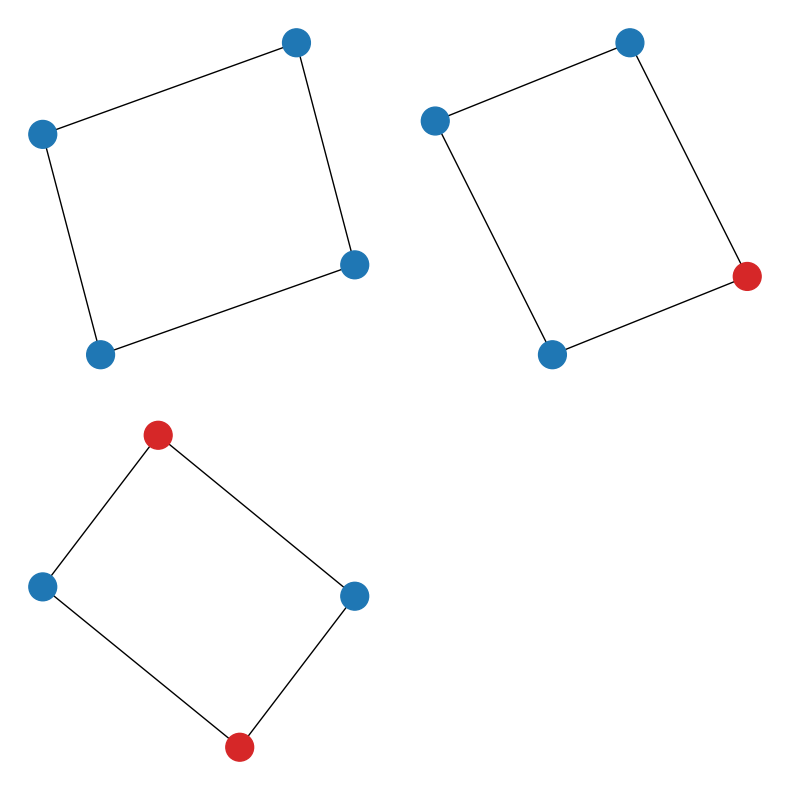

In [29]:
plot_graphs(indep_G4_v2)

In [30]:
G6 = get_colored_graphs(6)

In [31]:
print(len(G6))


114


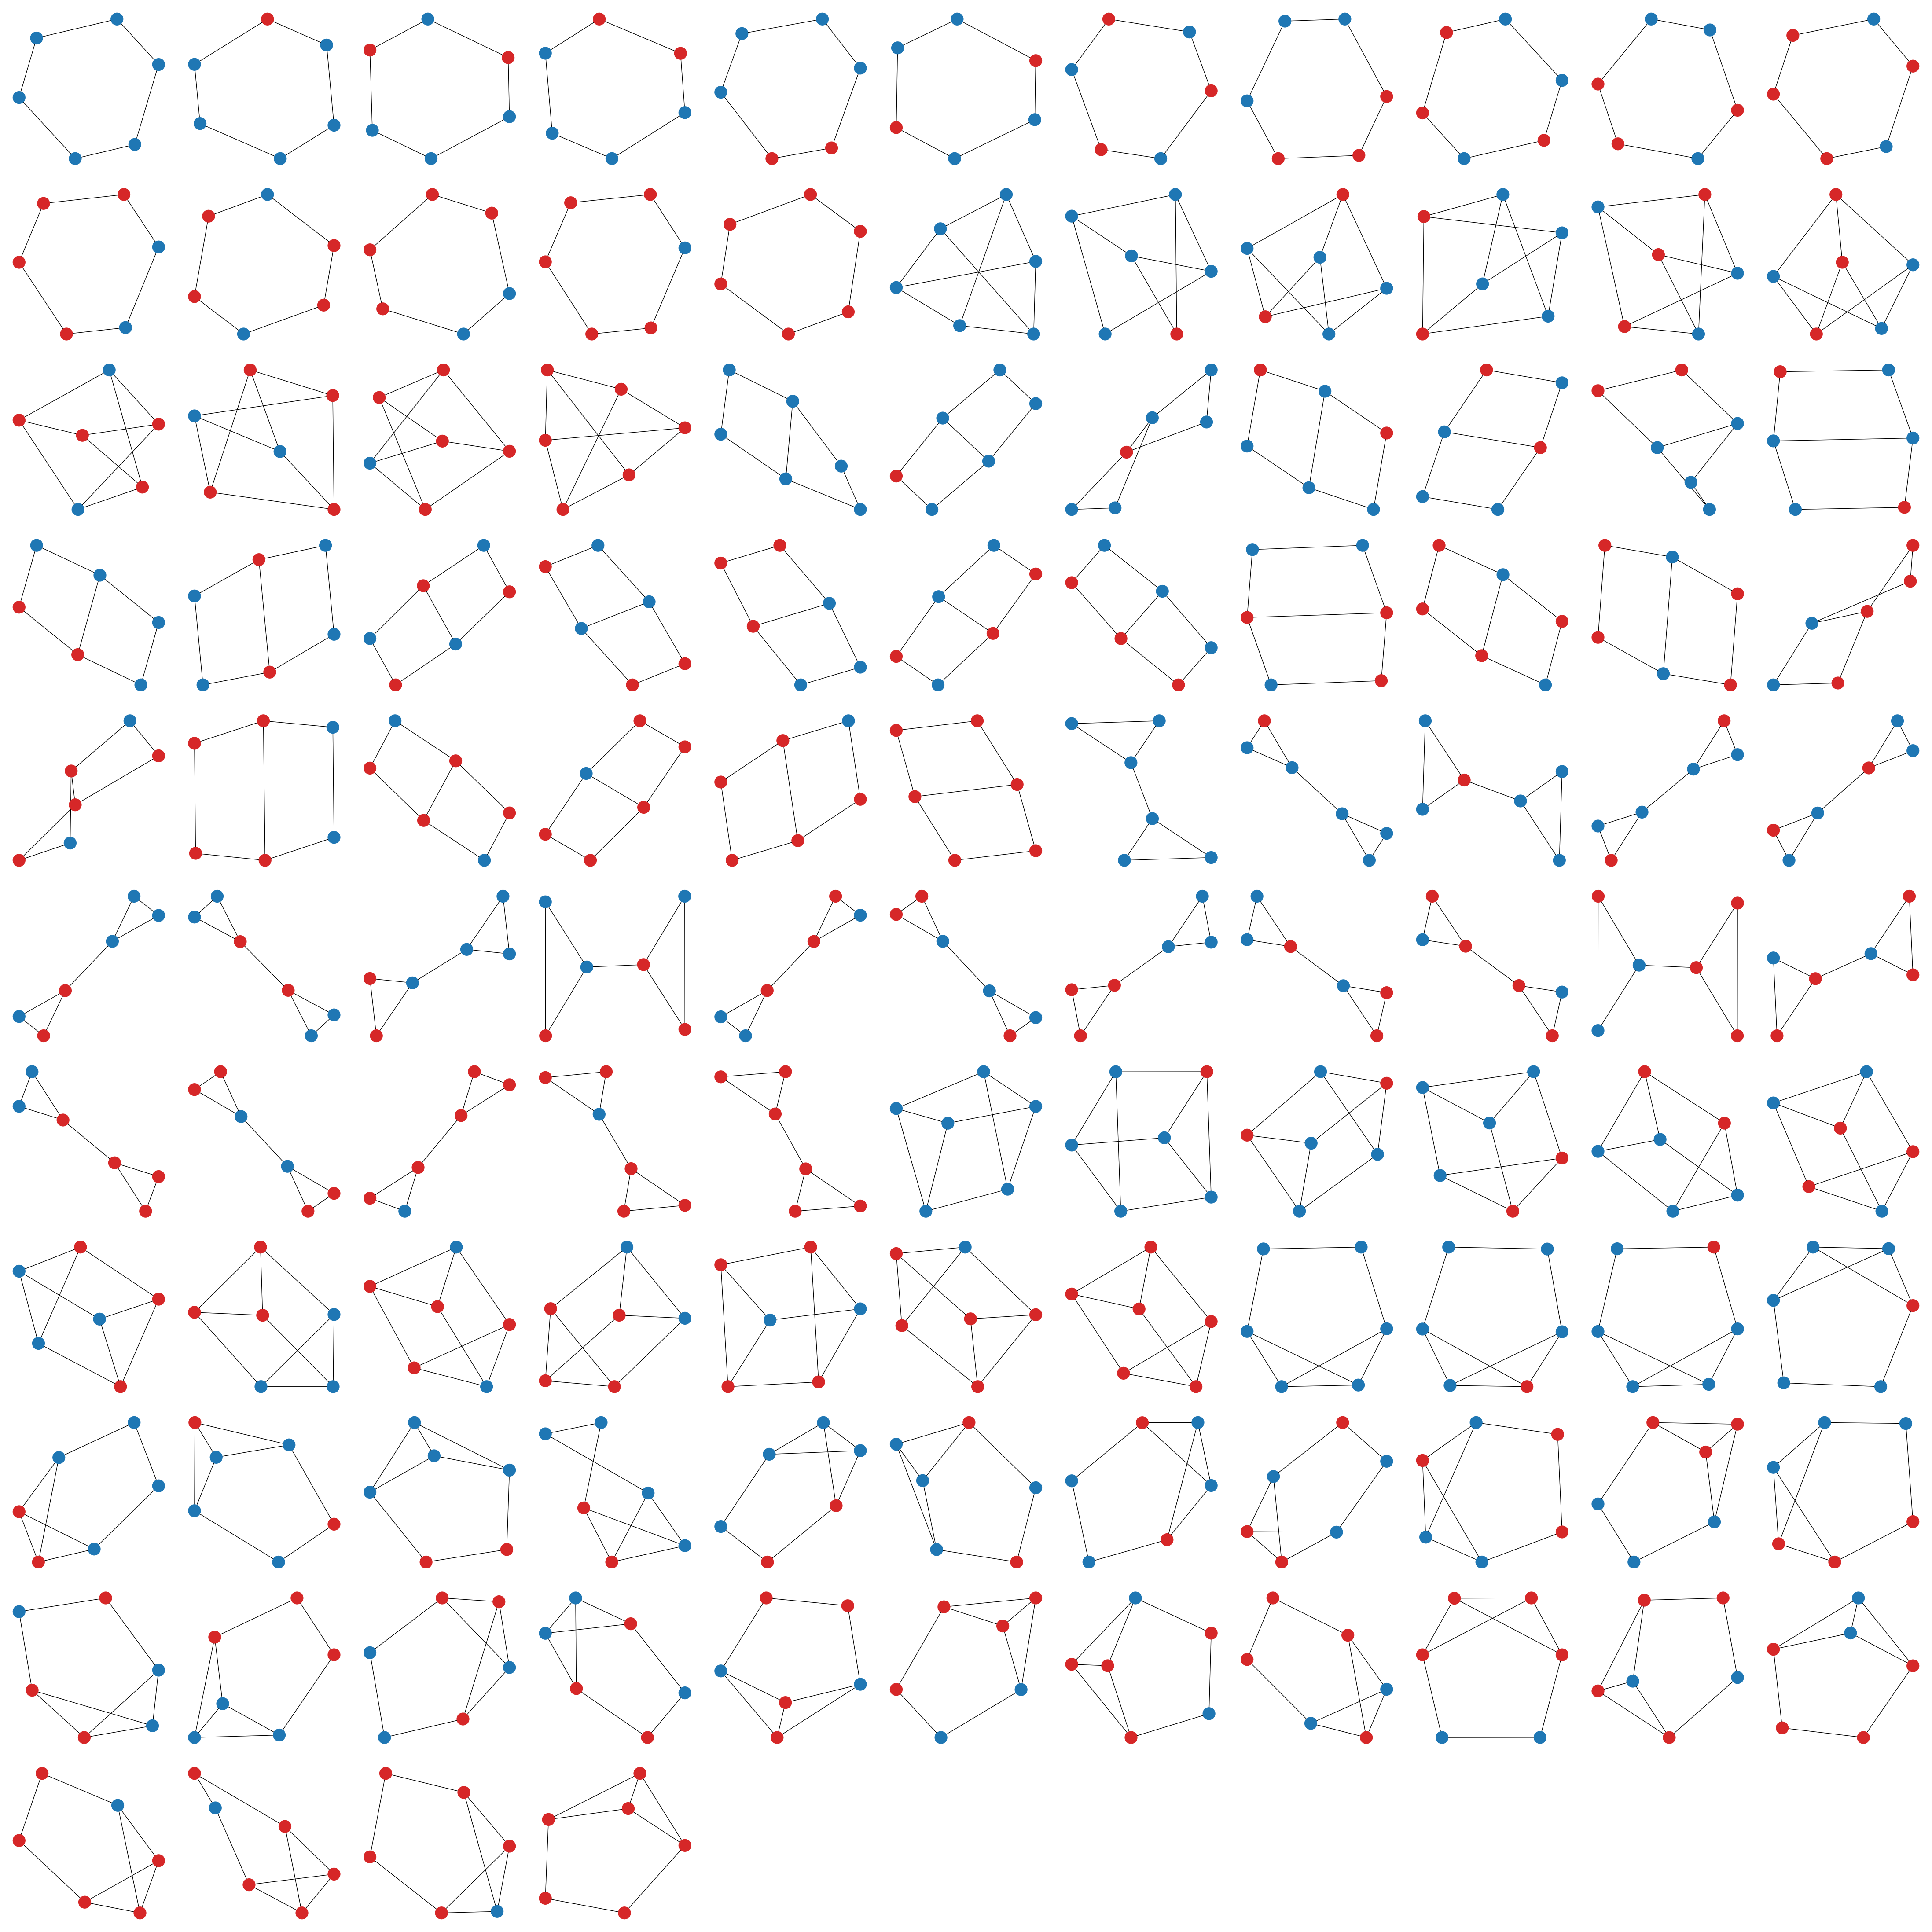

In [32]:
plot_graphs(G6)

In [33]:
data = []

for trial in range(114):
    H     = random_antisym(6, 3)
    Hstar = hodge_dual(H)
    row   = []

    # G4 is your list of order-4 colored graphs
    for G in G6:
        # 1) build the einsum pattern
        pattern = graph_to_einsum(G)               # e.g. "abc,abc" or similar

        # 2) read off each node’s color
        color_attr = nx.get_node_attributes(G, "color")
        #    color 0 → use H, color 1 → use Hstar
        #    nodes are labeled 0..N-1
        tensors = [ H if color_attr[i]==0 else Hstar
                    for i in range(G.number_of_nodes()) ]

        # 3) contract them in that order
        val = oe.contract(pattern, *tensors)
        row.append(float(val))

    data.append(row)

# now `data` is a 3×len(G4) array of floats


In [34]:
np.linalg.matrix_rank(data)

np.int64(5)

In [35]:
data = np.array(data).T.tolist()


In [36]:
indep_cols = []   # will hold the selected column-vectors
indep_idx  = []   # will hold their original column indices

for idx, vec in enumerate(data):
    # form the candidate matrix by stacking what we have + this new vec
    M = np.vstack(indep_cols + [vec])   # shape = (k+1, n_samples)

    # if the numeric rank goes up by exactly 1, this vec is independent
    if np.linalg.matrix_rank(M) == len(indep_cols) + 1:
        indep_cols.append(vec)
        indep_idx.append(idx)

print("Independent invariant indices:", indep_idx)

Independent invariant indices: [0, 1, 2, 3, 4]


In [37]:
indep_G6_v1 = [ G6[0], G6[1], G6[2], G6[3], G6[4] ]


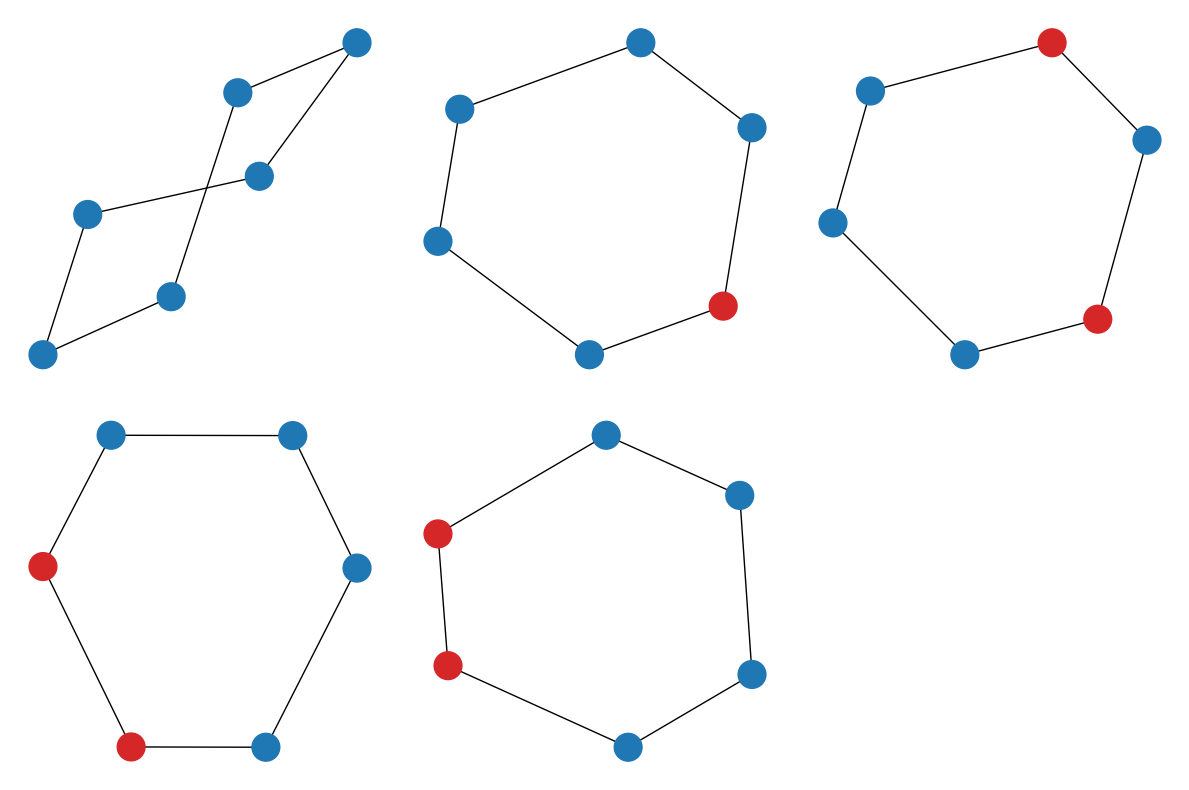

In [38]:
plot_graphs(indep_G6_v1)

In [39]:
data = []

for i in range(9):
    H = random_antisym(6, 3)
    Hstar = hodge_dual(H)
    row   = []
    y2 = []
    y4 =[]
    y6 =[]

    # G2 is your list of order-2 colored graphs
    for G in indep_G2:
        # 1) build the einsum pattern
        pattern = graph_to_einsum(G)               # e.g. "abc,abc" or similar

        # 2) read off each node’s color
        color_attr = nx.get_node_attributes(G, "color")
        #    color 0 → use H, color 1 → use Hstar
        #    nodes are labeled 0..N-1
        tensors = [ H if color_attr[i]==0 else Hstar
                    for i in range(G.number_of_nodes()) ]

        # 3) contract them in that order
        val = oe.contract(pattern, *tensors)
        y2.append((float(val)))


    for G in indep_G4_v2:
        # 1) build the einsum pattern
        pattern = graph_to_einsum(G)               # e.g. "abc,abc" or similar

        # 2) read off each node’s color
        color_attr = nx.get_node_attributes(G, "color")
        #    color 0 → use H, color 1 → use Hstar
        #    nodes are labeled 0..N-1
        tensors = [ H if color_attr[i]==0 else Hstar
                    for i in range(G.number_of_nodes()) ]

        # 3) contract them in that order
        val = oe.contract(pattern, *tensors)
        y4.append((float(val)))

    for G in indep_G6_v1:
        # 1) build the einsum pattern
        pattern = graph_to_einsum(G)               # e.g. "abc,abc" or similar

        # 2) read off each node’s color
        color_attr = nx.get_node_attributes(G, "color")
        #    color 0 → use H, color 1 → use Hstar
        #    nodes are labeled 0..N-1
        tensors = [ H if color_attr[i]==0 else Hstar
                    for i in range(G.number_of_nodes()) ]

        # 3) contract them in that order
        val = oe.contract(pattern, *tensors)
        y6.append((float(val)))

    row.append(y2[0]*y2[0]*y2[0])
    row.append(y2[0]*y4[0])
    row.append(y2[0]*y4[1])
    row.append(y2[0]*y4[2])
    row.append(y6[0])
    row.append(y6[1])
    row.append(y6[2])
    row.append(y6[3])
    row.append(y6[4])







    data.append(row)

data = np.matrix(data)

print(data.shape, np.linalg.matrix_rank(data))

(9, 9) 5


In [40]:
data = []

for i in range(5):
    H = random_antisym(6, 3)
    Hstar = hodge_dual(H)
    row   = []
    y2 = []
    y4 =[]
    y6 =[]

    # G2 is your list of order-2 colored graphs
    for G in indep_G2:
        # 1) build the einsum pattern
        pattern = graph_to_einsum(G)               # e.g. "abc,abc" or similar

        # 2) read off each node’s color
        color_attr = nx.get_node_attributes(G, "color")
        #    color 0 → use H, color 1 → use Hstar
        #    nodes are labeled 0..N-1
        tensors = [ H if color_attr[i]==0 else Hstar
                    for i in range(G.number_of_nodes()) ]

        # 3) contract them in that order
        val = oe.contract(pattern, *tensors)
        y2.append((float(val)))


    for G in indep_G4_v2:
        # 1) build the einsum pattern
        pattern = graph_to_einsum(G)               # e.g. "abc,abc" or similar

        # 2) read off each node’s color
        color_attr = nx.get_node_attributes(G, "color")
        #    color 0 → use H, color 1 → use Hstar
        #    nodes are labeled 0..N-1
        tensors = [ H if color_attr[i]==0 else Hstar
                    for i in range(G.number_of_nodes()) ]

        # 3) contract them in that order
        val = oe.contract(pattern, *tensors)
        y4.append((float(val)))

    for G in indep_G6_v1:
        # 1) build the einsum pattern
        pattern = graph_to_einsum(G)               # e.g. "abc,abc" or similar

        # 2) read off each node’s color
        color_attr = nx.get_node_attributes(G, "color")
        #    color 0 → use H, color 1 → use Hstar
        #    nodes are labeled 0..N-1
        tensors = [ H if color_attr[i]==0 else Hstar
                    for i in range(G.number_of_nodes()) ]

        # 3) contract them in that order
        val = oe.contract(pattern, *tensors)
        y6.append((float(val)))

    row.append(y2[0]*y2[0]*y2[0])
    row.append(y2[0]*y4[0])
    row.append(y2[0]*y4[1])
    row.append(y2[0]*y4[2])
    #row.append(y6[0])
    #row.append(y6[1])
    #row.append(y6[2])
    row.append(y6[3])
    #row.append(y6[4])







    data.append(row)

data = np.matrix(data)

print(data.shape, np.linalg.matrix_rank(data))

(5, 5) 5


In [41]:
indep_G6_v2 = [indep_G6_v1[3]]

In [42]:
G8 = get_colored_graphs(8)

In [43]:
print(len(G8))


1699


In [45]:
import numpy as np
import networkx as nx
import opt_einsum as oe
from joblib import Parallel, delayed
import multiprocessing

# ——— your imports ———
# from your_module import random_antisym, graph_to_einsum, get_colored_graphs

# 1) generate the 2-colored graphs on 8 nodes
n = G8[0].number_of_nodes()   # should be 8

# 2) extract einsum‐patterns
patterns = [graph_to_einsum(G) for G in G8]

# 3) precompute optimal contraction‐paths once, using a dummy H_ref of the correct shape
H_ref = random_antisym(6, 3)

def _compute_path(pattern):
    # all placeholders have the same shape, so we pass H_ref n times
    return oe.contract_path(pattern, *([H_ref] * n))[0]

paths = Parallel(n_jobs=-1, backend='threading')(
    delayed(_compute_path)(pat) for pat in patterns
)

# 4) define function to build one row of the big matrix
def compute_y8(i):
    H      = random_antisym(6, 3)
    Hstar  = hodge_dual(H)
    row = []
    for ig, G in enumerate(G8):
        pat = patterns[ig]
        color_attr = nx.get_node_attributes(G, "color")
        # choose H or Hstar per node color
        tensors = [H if color_attr[node] == 0 else Hstar
                   for node in range(n)]
        val = oe.contract(pat, *tensors, optimize=paths[ig])
        row.append(float(val))
    return row

# 5) build the full data matrix in parallel
data = Parallel(n_jobs=-1, backend='threading')(
    delayed(compute_y8)(i) for i in range(len(G8))
)

data = np.array(data)
print(f"Number of graphs: {len(G8)}")
print("Matrix rank:", np.linalg.matrix_rank(data))


Number of graphs: 1699
Matrix rank: 11


In [46]:
np.linalg.matrix_rank(data)

np.int64(11)

In [47]:
data = np.array(data).T.tolist()


In [48]:
indep_cols = []   # will hold the selected column-vectors
indep_idx  = []   # will hold their original column indices

for idx, vec in enumerate(data):
    # form the candidate matrix by stacking what we have + this new vec
    M = np.vstack(indep_cols + [vec])   # shape = (k+1, n_samples)

    # if the numeric rank goes up by exactly 1, this vec is independent
    if np.linalg.matrix_rank(M) == len(indep_cols) + 1:
        indep_cols.append(vec)
        indep_idx.append(idx)

print("Independent invariant indices:", indep_idx)

Independent invariant indices: [0, 1, 2, 5, 6, 11, 12, 13, 14, 21, 49]


In [49]:
indep_G8_v1 = [G8[0],  G8[1],  G8[2],  G8[5],  G8[6],  G8[11],  G8[12],  G8[13],  G8[14],  G8[21],  G8[49] ]


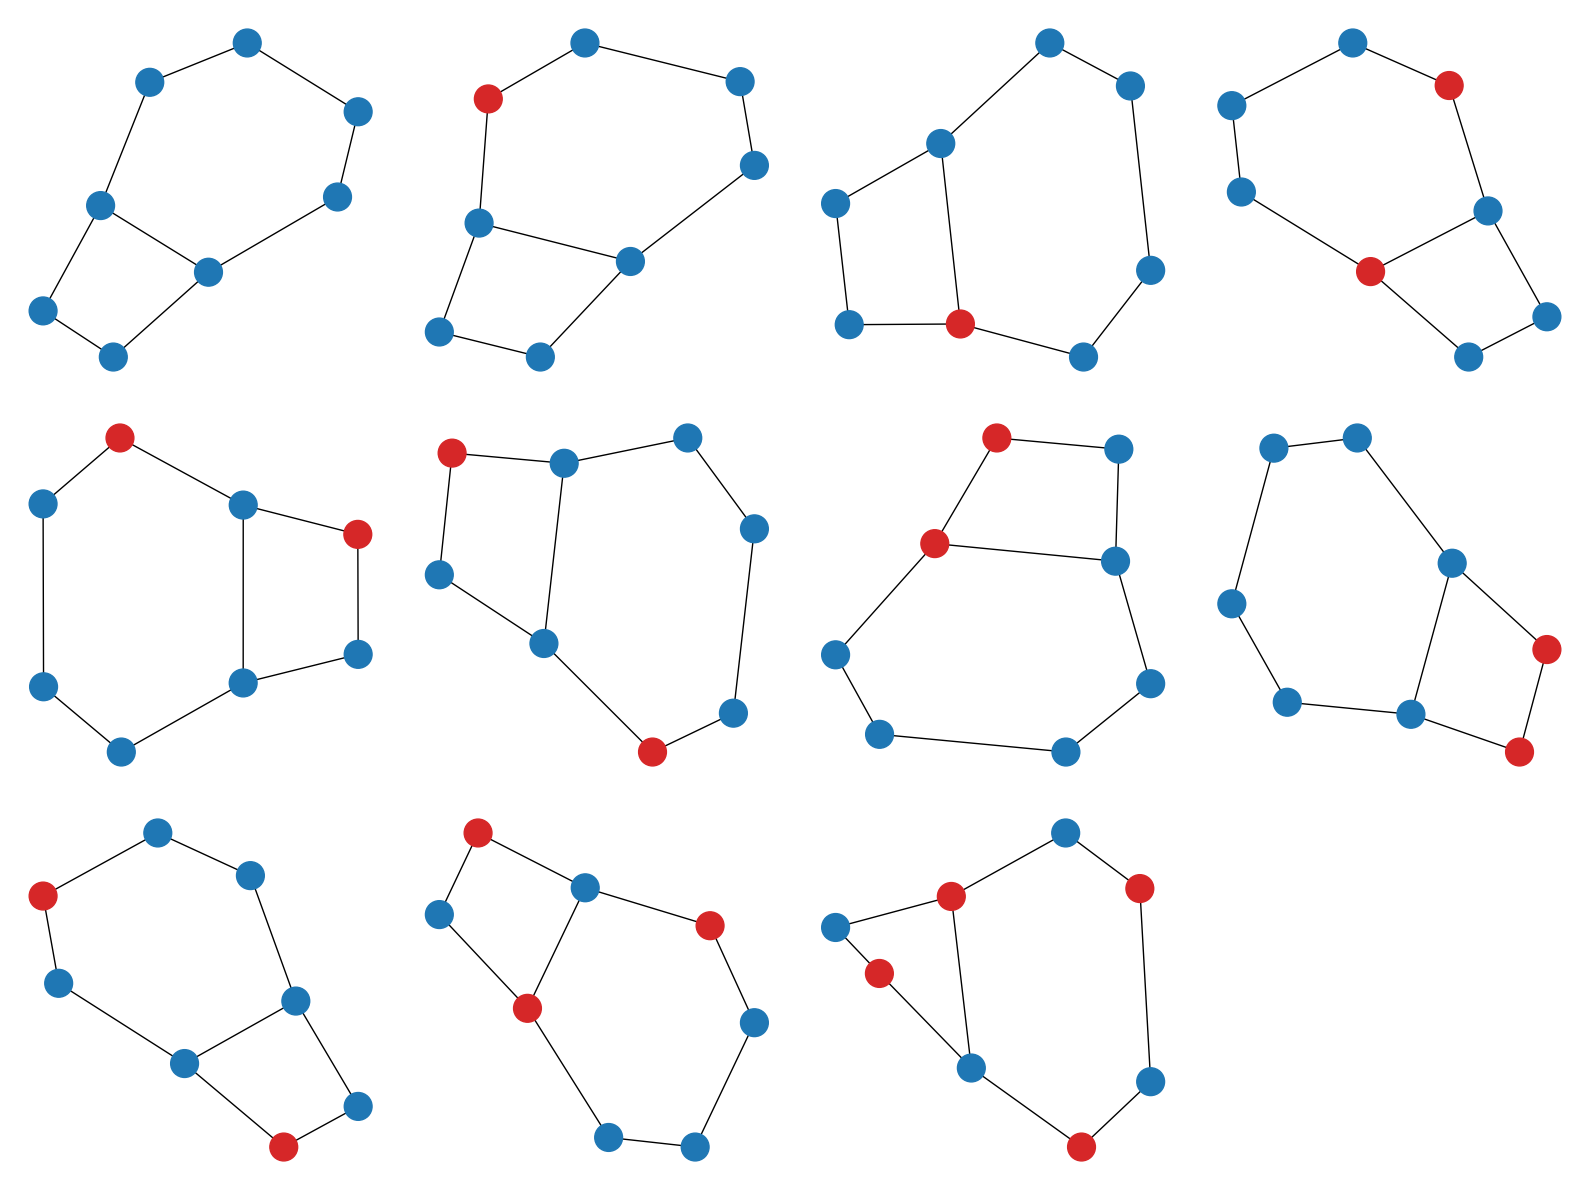

In [50]:
plot_graphs(indep_G8_v1)

In [51]:
#Now adding in all the order 8 invariants, and we end up seeing they are all dependent

data = []

for i in range(22):
    H = random_antisym(6, 3)
    Hstar = hodge_dual(H)
    row   = []
    y2 = []
    y4 =[]
    y6=[]
    y8 =[]

    # G2 is your list of order-2 colored graphs
    for G in G2:
        # 1) build the einsum pattern
        pattern = graph_to_einsum(G)               # e.g. "abc,abc" or similar

        # 2) read off each node’s color
        color_attr = nx.get_node_attributes(G, "color")
        #    color 0 → use H, color 1 → use Hstar
        #    nodes are labeled 0..N-1
        tensors = [ H if color_attr[i]==0 else Hstar
                    for i in range(G.number_of_nodes()) ]

        # 3) contract them in that order
        val = oe.contract(pattern, *tensors)
        y2.append((float(val)))


    for G in indep_G4_v2:
        # 1) build the einsum pattern
        pattern = graph_to_einsum(G)               # e.g. "abc,abc" or similar

        # 2) read off each node’s color
        color_attr = nx.get_node_attributes(G, "color")
        #    color 0 → use H, color 1 → use Hstar
        #    nodes are labeled 0..N-1
        tensors = [ H if color_attr[i]==0 else Hstar
                    for i in range(G.number_of_nodes()) ]

        # 3) contract them in that order
        val = oe.contract(pattern, *tensors)
        y4.append((float(val)))

    for G in indep_G6_v2:
        # 1) build the einsum pattern
        pattern = graph_to_einsum(G)               # e.g. "abc,abc" or similar

        # 2) read off each node’s color
        color_attr = nx.get_node_attributes(G, "color")
        #    color 0 → use H, color 1 → use Hstar
        #    nodes are labeled 0..N-1
        tensors = [ H if color_attr[i]==0 else Hstar
                    for i in range(G.number_of_nodes()) ]

        # 3) contract them in that order
        val = oe.contract(pattern, *tensors)
        y6.append((float(val)))

    for G in indep_G8_v1:
        # 1) build the einsum pattern
        pattern = graph_to_einsum(G)               # e.g. "abc,abc" or similar

        # 2) read off each node’s color
        color_attr = nx.get_node_attributes(G, "color")
        #    color 0 → use H, color 1 → use Hstar
        #    nodes are labeled 0..N-1
        tensors = [ H if color_attr[i]==0 else Hstar
                    for i in range(G.number_of_nodes()) ]

        # 3) contract them in that order
        val = oe.contract(pattern, *tensors)
        y8.append((float(val)))

    row.append(y2[0]*y2[0]*y2[0]*y2[0])
    row.append(y4[0]*y4[0])
    row.append(y4[0]*y4[1])
    row.append(y4[0]*y4[2])
    row.append(y4[1]*y4[1])
    row.append(y4[1]*y4[2])
    row.append(y4[2]*y4[2])
    row.append(y2[0]*y2[0]*y4[0])
    row.append(y2[0]*y2[0]*y4[1])
    row.append(y2[0]*y2[0]*y4[2])
    row.append(y2[0]*y6[0])
    row.append(y8[0])
    row.append(y8[1])
    row.append(y8[2])
    row.append(y8[3])
    row.append(y8[4])
    row.append(y8[5])
    row.append(y8[6])
    row.append(y8[7])
    row.append(y8[8])
    row.append(y8[9])
    row.append(y8[10])


    data.append(row)

data = np.matrix(data)

print(data.shape, np.linalg.matrix_rank(data))

(22, 22) 11


In [52]:

data = []

for i in range(11):
    H = random_antisym(6, 3)
    Hstar = hodge_dual(H)
    row   = []
    y2 = []
    y4 =[]
    y6=[]
    y8 =[]

    # G2 is your list of order-2 colored graphs
    for G in indep_G2:
        # 1) build the einsum pattern
        pattern = graph_to_einsum(G)               # e.g. "abc,abc" or similar

        # 2) read off each node’s color
        color_attr = nx.get_node_attributes(G, "color")
        #    color 0 → use H, color 1 → use Hstar
        #    nodes are labeled 0..N-1
        tensors = [ H if color_attr[i]==0 else Hstar
                    for i in range(G.number_of_nodes()) ]

        # 3) contract them in that order
        val = oe.contract(pattern, *tensors)
        y2.append((float(val)))


    for G in indep_G4_v2:
        # 1) build the einsum pattern
        pattern = graph_to_einsum(G)               # e.g. "abc,abc" or similar

        # 2) read off each node’s color
        color_attr = nx.get_node_attributes(G, "color")
        #    color 0 → use H, color 1 → use Hstar
        #    nodes are labeled 0..N-1
        tensors = [ H if color_attr[i]==0 else Hstar
                    for i in range(G.number_of_nodes()) ]

        # 3) contract them in that order
        val = oe.contract(pattern, *tensors)
        y4.append((float(val)))

    for G in indep_G6_v2:
        # 1) build the einsum pattern
        pattern = graph_to_einsum(G)               # e.g. "abc,abc" or similar

        # 2) read off each node’s color
        color_attr = nx.get_node_attributes(G, "color")
        #    color 0 → use H, color 1 → use Hstar
        #    nodes are labeled 0..N-1
        tensors = [ H if color_attr[i]==0 else Hstar
                    for i in range(G.number_of_nodes()) ]

        # 3) contract them in that order
        val = oe.contract(pattern, *tensors)
        y6.append((float(val)))

   # for G in indep_G8_v1:
        # 1) build the einsum pattern
    #    pattern = graph_to_einsum(G)               # e.g. "abc,abc" or similar

        # 2) read off each node’s color
     #   color_attr = nx.get_node_attributes(G, "color")
        #    color 0 → use H, color 1 → use Hstar
        #    nodes are labeled 0..N-1
      #  tensors = [ H if color_attr[i]==0 else Hstar
       #             for i in range(G.number_of_nodes()) ]

        # 3) contract them in that order
        #val = oe.contract(pattern, *tensors)
        #y8.append((float(val)))

    row.append(y2[0]*y2[0]*y2[0]*y2[0])
    row.append(y4[0]*y4[0])
    row.append(y4[0]*y4[1])
    row.append(y4[0]*y4[2])
    row.append(y4[1]*y4[1])
    row.append(y4[1]*y4[2])
    row.append(y4[2]*y4[2])
    row.append(y2[0]*y2[0]*y4[0])
    row.append(y2[0]*y2[0]*y4[1])
    row.append(y2[0]*y2[0]*y4[2])
    row.append(y2[0]*y6[0])
    #row.append(y8[0])
    #row.append(y8[1])
    #row.append(y8[2])
    #row.append(y8[3])
    #row.append(y8[4])
    #row.append(y8[5])
    #row.append(y8[6])
    #row.append(y8[7])
    #row.append(y8[8])
    #row.append(y8[9])
    #row.append(y8[10])


    data.append(row)

data = np.matrix(data)

print(data.shape, np.linalg.matrix_rank(data))

(11, 11) 11


In [53]:
#Order 10 independence checks (redundant, since the next cell does this same thing but also goes onto higher orders)


data = []

for i in range(14):
    H = random_antisym(6, 3)
    Hstar = hodge_dual(H)
    row   = []
    y2 = []
    y4 =[]
    y6=[]
    y8 =[]

    # G2 is your list of order-2 colored graphs
    for G in indep_G2:
        # 1) build the einsum pattern
        pattern = graph_to_einsum(G)               # e.g. "abc,abc" or similar

        # 2) read off each node’s color
        color_attr = nx.get_node_attributes(G, "color")
        #    color 0 → use H, color 1 → use Hstar
        #    nodes are labeled 0..N-1
        tensors = [ H if color_attr[i]==0 else Hstar
                    for i in range(G.number_of_nodes()) ]

        # 3) contract them in that order
        val = oe.contract(pattern, *tensors)
        y2.append((float(val)))


    for G in indep_G4_v2:
        # 1) build the einsum pattern
        pattern = graph_to_einsum(G)               # e.g. "abc,abc" or similar

        # 2) read off each node’s color
        color_attr = nx.get_node_attributes(G, "color")
        #    color 0 → use H, color 1 → use Hstar
        #    nodes are labeled 0..N-1
        tensors = [ H if color_attr[i]==0 else Hstar
                    for i in range(G.number_of_nodes()) ]

        # 3) contract them in that order
        val = oe.contract(pattern, *tensors)
        y4.append((float(val)))

    for G in indep_G6_v2:
        # 1) build the einsum pattern
        pattern = graph_to_einsum(G)               # e.g. "abc,abc" or similar

        # 2) read off each node’s color
        color_attr = nx.get_node_attributes(G, "color")
        #    color 0 → use H, color 1 → use Hstar
        #    nodes are labeled 0..N-1
        tensors = [ H if color_attr[i]==0 else Hstar
                    for i in range(G.number_of_nodes()) ]

        # 3) contract them in that order
        val = oe.contract(pattern, *tensors)
        y6.append((float(val)))

   # for G in indep_G8_v1:
        # 1) build the einsum pattern
    #    pattern = graph_to_einsum(G)               # e.g. "abc,abc" or similar

        # 2) read off each node’s color
     #   color_attr = nx.get_node_attributes(G, "color")
        #    color 0 → use H, color 1 → use Hstar
        #    nodes are labeled 0..N-1
      #  tensors = [ H if color_attr[i]==0 else Hstar
       #             for i in range(G.number_of_nodes()) ]

        # 3) contract them in that order
        #val = oe.contract(pattern, *tensors)
        #y8.append((float(val)))

    row.append(y4[0]*y6[0])
    row.append(y4[1]*y6[0])
    row.append(y4[2]*y6[0])

    row.append(y2[0]* y2[0]*y6[0])

    row.append(y4[0]*y4[0]* y2[0])
    row.append(y4[0]*y4[1]* y2[0])
    row.append(y4[0]*y4[2]* y2[0])
    row.append(y4[1]*y4[1]* y2[0])
    row.append(y4[1]*y4[2]* y2[0])
    row.append(y4[2]*y4[2]* y2[0])

    row.append(y2[0]*y2[0]* y2[0]*y4[0])
    row.append(y2[0]*y2[0]* y2[0]*y4[1])
    row.append(y2[0]*y2[0]* y2[0] *y4[2])

    row.append(y2[0]*y2[0]*y2[0]*y2[0] * y2[0])

    data.append(row)

data = np.matrix(data)

print(data.shape, np.linalg.matrix_rank(data))

(14, 14) 14


In [54]:
import numpy as np
from itertools import product
import networkx as nx
import opt_einsum as oe

def generate_monomials(target_sum):
    monomials = []
    for a in range(target_sum // 2 + 1):
        for b0 in range(target_sum // 4 + 1):
            for b1 in range(target_sum // 4 + 1):
                for b2 in range(target_sum // 4 + 1):
                    for c in range(target_sum // 6 + 1):
                        total = 2*a + 4*(b0 + b1 + b2) + 6*c
                        if total == target_sum:
                            monomials.append((a, b0, b1, b2, c))
    return monomials

for total_order in range(10, 51, 2):
    monomials = generate_monomials(total_order)
    data = []

    for _ in range(len(monomials)):
        H = random_antisym(6, 3)
        Hstar = hodge_dual(H)

        y2 = []
        y4 = []
        y6 = []

        for G in indep_G2:
            pattern = graph_to_einsum(G)
            color_attr = nx.get_node_attributes(G, "color")
            tensors = [H if color_attr[i] == 0 else Hstar for i in range(G.number_of_nodes())]
            val = oe.contract(pattern, *tensors)
            y2.append(float(val))

        for G in indep_G4_v2:
            pattern = graph_to_einsum(G)
            color_attr = nx.get_node_attributes(G, "color")
            tensors = [H if color_attr[i] == 0 else Hstar for i in range(G.number_of_nodes())]
            val = oe.contract(pattern, *tensors)
            y4.append(float(val))

        for G in indep_G6_v2:
            pattern = graph_to_einsum(G)
            color_attr = nx.get_node_attributes(G, "color")
            tensors = [H if color_attr[i] == 0 else Hstar for i in range(G.number_of_nodes())]
            val = oe.contract(pattern, *tensors)
            y6.append(float(val))

        row = []
        for a, b0, b1, b2, c in monomials:
            val = (y2[0] ** a) * (y4[0] ** b0) * (y4[1] ** b1) * (y4[2] ** b2) * (y6[0] ** c)
            row.append(val)

        data.append(row)

    data = np.array(data)

    # your matrix
    A = data

    # singular values
    _, S, _ = np.linalg.svd(A)

    # custom fixed threshold (say 1e-6)
    fixed_tol = 1e-6

    # count singular values above that threshold
    rank = np.sum(S > fixed_tol)

    print(f"Order {total_order}: shape = {data.shape}, rank = {rank}")


Order 10: shape = (14, 14), rank = 14
Order 12: shape = (25, 25), rank = 25
Order 14: shape = (31, 31), rank = 31
Order 16: shape = (49, 49), rank = 49
Order 18: shape = (60, 60), rank = 60
Order 20: shape = (87, 87), rank = 87
Order 22: shape = (105, 105), rank = 105
Order 24: shape = (144, 144), rank = 144
Order 26: shape = (171, 171), rank = 171
Order 28: shape = (225, 225), rank = 225
Order 30: shape = (264, 264), rank = 264
Order 32: shape = (336, 336), rank = 336
Order 34: shape = (390, 390), rank = 390
Order 36: shape = (484, 484), rank = 484
Order 38: shape = (556, 556), rank = 556
Order 40: shape = (676, 676), rank = 676
Order 42: shape = (770, 770), rank = 770
Order 44: shape = (920, 920), rank = 920
Order 46: shape = (1040, 1040), rank = 1040
Order 48: shape = (1225, 1225), rank = 1225
Order 50: shape = (1375, 1375), rank = 1375


In [55]:
import networkx as nx

def export_x_graphs(
    indep_G2,
    indep_G4_v2,
    indep_G6_v2,

):
    """
    Generates Python code that reconstructs:
      x1 ← indep_G2[0]
      x2 ← indep_G4_v2[0]
      x3 ← indep_G4_v2[1]
      x4 ← indep_G4_v2[2]
      x5 ← indep_G6_v2[0]

    including node‐"color" and edge‐"weight" attributes.
    """
    lines = ["import networkx as nx", ""]

    # Map x‐labels to their source graphs
    x_sources = {
        "x1": indep_G2[0],
        "x2": indep_G4_v2[0],
        "x3": indep_G4_v2[1],
        "x4": indep_G4_v2[2],
        "x5": indep_G6_v2[0],
    }

    # Function to export a single graph under a given varname
    def _export_graph(varname, G):
        lines.append(f"# --- {varname} definition")
        lines.append(f"{varname} = nx.Graph()")
        # nodes
        node_list = list(G.nodes())
        lines.append(f"{varname}.add_nodes_from({node_list})")
        # colors
        color_dict = nx.get_node_attributes(G, "color")
        for node, color in color_dict.items():
            lines.append(f"{varname}.nodes[{node}]['color'] = {color}")
        # edges with weights
        for u, v, data in G.edges(data=True):
            w = data.get("weight", 1)
            lines.append(f"{varname}.add_edge({u}, {v}, weight={w})")
        lines.append("")  # blank line

    # Export x1..x5
    for varname, G in x_sources.items():
        _export_graph(varname, G)

    # Export y1..y5


    return "\n".join(lines)


# Example usage:
code_string = export_x_graphs(
    indep_G2,
    indep_G4_v2,
    indep_G6_v2,

)
print(code_string)


import networkx as nx

# --- x1 definition
x1 = nx.Graph()
x1.add_nodes_from([0, 1])
x1.nodes[0]['color'] = 0
x1.nodes[1]['color'] = 0
x1.add_edge(0, 1, weight=3)

# --- x2 definition
x2 = nx.Graph()
x2.add_nodes_from([0, 1, 2, 3])
x2.nodes[0]['color'] = 0
x2.nodes[1]['color'] = 0
x2.nodes[2]['color'] = 0
x2.nodes[3]['color'] = 0
x2.add_edge(0, 2, weight=1)
x2.add_edge(0, 3, weight=2)
x2.add_edge(1, 2, weight=2)
x2.add_edge(1, 3, weight=1)

# --- x3 definition
x3 = nx.Graph()
x3.add_nodes_from([0, 1, 2, 3])
x3.nodes[0]['color'] = 0
x3.nodes[1]['color'] = 0
x3.nodes[2]['color'] = 0
x3.nodes[3]['color'] = 1
x3.add_edge(0, 2, weight=1)
x3.add_edge(0, 3, weight=2)
x3.add_edge(1, 2, weight=2)
x3.add_edge(1, 3, weight=1)

# --- x4 definition
x4 = nx.Graph()
x4.add_nodes_from([0, 1, 2, 3])
x4.nodes[0]['color'] = 0
x4.nodes[1]['color'] = 0
x4.nodes[2]['color'] = 1
x4.nodes[3]['color'] = 1
x4.add_edge(0, 2, weight=1)
x4.add_edge(0, 3, weight=2)
x4.add_edge(1, 2, weight=2)
x4.add_edge(1, 3, weig